## **Data Preprocessing**

### Import Dependencies


In [1]:
#Import required frameworks 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Store Data as Local Variable

Store CSV data into a `pandas` frame to allow data adjustments


In [2]:
data_frame = pd.read_csv("2.1.val_ds.csv")

### View data

View dataset and analyse dataset

In [3]:
data_frame.head()
data_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  579 non-null    str    
 1   rank                579 non-null    str    
 2   win%                579 non-null    float64
 3   k/d                 579 non-null    float64
 4   dmg/rnd             579 non-null    float64
 5   region              563 non-null    str    
 6   acc_head_%          579 non-null    float64
 7   acc_head_hits       579 non-null    int64  
 8   acc_body_%          579 non-null    float64
 9   acc_body_hits       579 non-null    int64  
 10  acc_leg_%           579 non-null    float64
 11  acc_leg_hits        579 non-null    int64  
 12  matchs_played       579 non-null    str    
 13  headshot_%          579 non-null    float64
 14  wins_total          579 non-null    str    
 15  kills_total         579 non-null    str    
 16  avg_kill_per_rnd   

### Adjust data 

There are no `NULL` values so that's a positive, however some data is unnecessarily exposing privacy or has no relevance to my aim thus it can be removed. There are also some features (matchs_played, wins_total, kills_total), that despite being a numerical character are still represented as a string which will interfere with my feature engineering, thus I should convert these features as well. 

First I'll start with `drop()` to remove the appropriate columns



In [4]:
#Remove unnecessary data

data_frame1 = data_frame.drop(columns=[
    'top_agent_nam', 'top_agent_time_hrs', "top_agent_matchs", 
    'top_agent_win_%', 'acc_head_%', 'acc_body_%', 'acc_leg_%',
    'acc_head_hits', 'acc_body_hits', 'acc_leg_hits',
    'top_agent_kd_avg', 'top_agent_adr', 'id', 'region'
    ])

data_frame1.info()

<class 'pandas.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rank              579 non-null    str    
 1   win%              579 non-null    float64
 2   k/d               579 non-null    float64
 3   dmg/rnd           579 non-null    float64
 4   matchs_played     579 non-null    str    
 5   headshot_%        579 non-null    float64
 6   wins_total        579 non-null    str    
 7   kills_total       579 non-null    str    
 8   avg_kill_per_rnd  579 non-null    float64
dtypes: float64(5), str(4)
memory usage: 40.8 KB


### Convert Data to appropriate data type

Now I must change the data types of the 3 categories to float to allow the model to conduct calculations and to prevent issues when feature engineering.

I will also one-hot encode the ranks for later implementation with neural networks

In [5]:
# Convert matches_played from str to float
data_frame1['matchs_played'] = data_frame1['matchs_played'].str.replace(',','').astype(float)

# Convert matches_played from str to float
data_frame1["wins_total"] = data_frame1["wins_total"].str.replace(',','').astype(float)

# Convert matches_played from str to float
data_frame1["kills_total"] = data_frame1["kills_total"].str.replace(',','').astype(float)

# View new dataset
data_frame1.info()

<class 'pandas.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rank              579 non-null    str    
 1   win%              579 non-null    float64
 2   k/d               579 non-null    float64
 3   dmg/rnd           579 non-null    float64
 4   matchs_played     579 non-null    float64
 5   headshot_%        579 non-null    float64
 6   wins_total        579 non-null    float64
 7   kills_total       579 non-null    float64
 8   avg_kill_per_rnd  579 non-null    float64
dtypes: float64(8), str(1)
memory usage: 40.8 KB


### One Hot Encode Rank category

My main is to merge the each subdivision from each rank into just the initial rank to simplify classification targets. I'll use the in-built pandas one-hot encode method, I also attempted to replace all values in a singular line but found out that apparently `replace()` returns a pandas `Series` thus I have to create multiple lines. The last line I had to search up due to there being too many individual categories.



In [6]:
# Begin with simplifying category
data_frame1["rank"] = data_frame1["rank"].str.strip().str.replace("1", "")
data_frame1["rank"] = data_frame1["rank"].str.strip().str.replace("2", "")
data_frame1["rank"] = data_frame1["rank"].str.strip().str.replace("3", "")

# One Hot Encode
data_frame2 = pd.get_dummies(data_frame1, columns=['rank'])

# View new Data
data_frame2.filter(like='rank_').head()

,rank_Ascendant,rank_Ascendant,rank_Bronze,rank_Bronze,rank_Diamond,rank_Diamond,rank_Gold,rank_Gold,rank_Immortal,rank_Immortal,rank_Iron,rank_Iron,rank_Platinum,rank_Platinum,rank_Radiant,rank_Silver,rank_Silver,rank_Unranked
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False


### View final dataset

By analysing dataset through a statistical lens I can understand what features need to be re-adjusted. Example, altering categorical to numerical through `one-hot coding`. I can also figure out scaling parameters for model based off of raw data.

Notes:
- I can round this data as majority of it doesn't have to be too specific
- The business problem also doesn't require such specification
- Leave some space just for scaling just in case

In [7]:
data_frame2.describe().round(2)

,win%,k/d,dmg/rnd,matchs_played,headshot_%,wins_total,kills_total,avg_kill_per_rnd
count,579.00,579.00,579.00,579.00,579.00,579.00,579.00,579.00
mean,51.24,1.07,144.26,610.94,16.44,302.31,9437.09,0.72
std,12.16,0.25,26.07,775.54,5.55,379.96,12337.06,0.17
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,46.00,0.94,130.15,162.00,13.30,82.50,2369.00,0.70
50%,50.90,1.05,144.90,390.00,16.10,196.00,5961.00,0.70
75%,57.10,1.16,156.45,781.00,19.90,391.00,12339.50,0.80
max,100.00,2.66,247.40,11259.00,30.90,5471.00,190369.00,1.10


### Save new dataset

In [8]:
data_frame2.to_csv("../2.2.Feature_Engineering/2.2.1.wrangled_val_ds.csv", index=False)

### Plot Data using matplotlib

Check the initial spread of data to see their consistency and identify potential relationships. This also helps me figure out whether certain feature needs to be dropped.

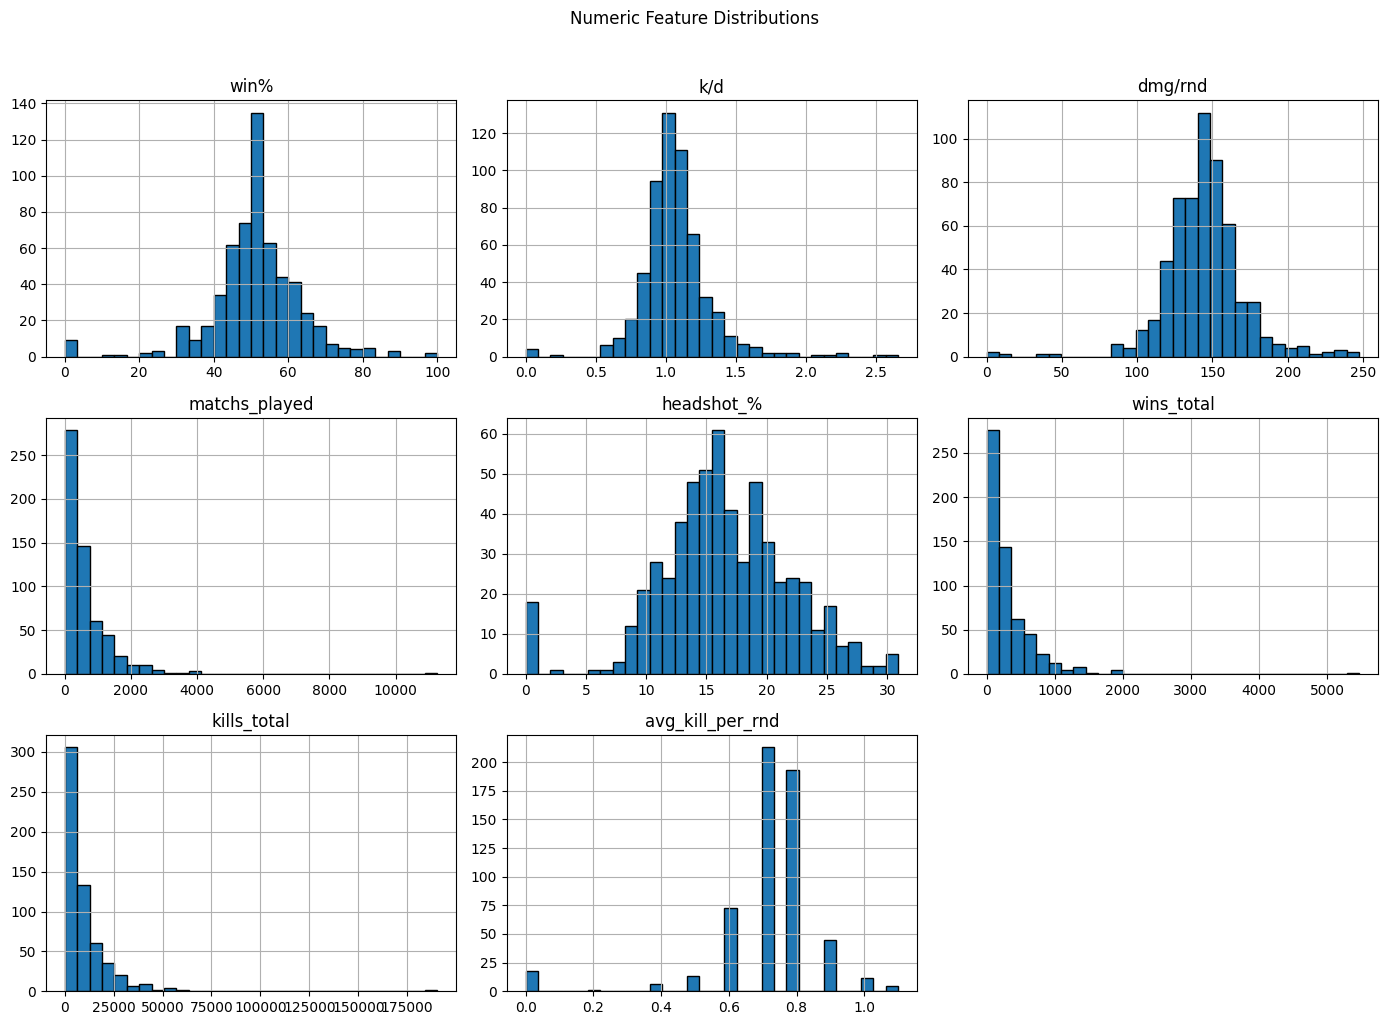

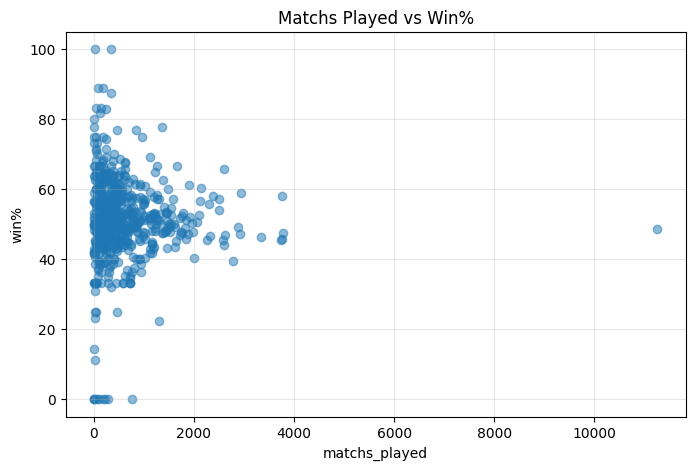

In [9]:
# Plot numeric distributions from data_frame1
numeric_cols = data_frame1.select_dtypes(include=["number"]).columns

data_frame1[numeric_cols].hist(figsize=(14, 10), bins=30, edgecolor="black")
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

# Example relationship plot: matches played vs win%
plt.figure(figsize=(8, 5))
plt.scatter(data_frame1["matchs_played"], data_frame1["win%"], alpha=0.5)
plt.title("Matchs Played vs Win%")
plt.xlabel("matchs_played")
plt.ylabel("win%")
plt.grid(True, alpha=0.3)
plt.show()

### Compare different features to find correlation

Compare features against one another to identify the strongest relationships thus features

### Linear comparison

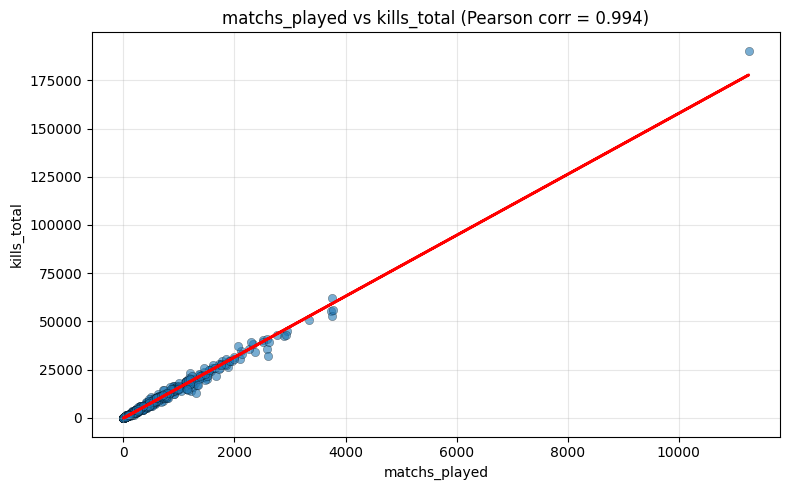

Pearson correlation between 'matchs_played' and 'kills_total': 0.994


In [10]:
def plot_feature_correlation(df, x_col, y_col, method="pearson"):
    """
    Plot two features and print their correlation.

    Parameters:
        df (pd.DataFrame): Source dataframe
        x_col (str): Feature for x-axis
        y_col (str): Feature for y-axis
        method (str): Correlation method ('pearson', 'spearman', 'kendall')
    """
    # Convert selected columns to numeric if needed
    x = pd.to_numeric(df[x_col], errors="coerce")
    y = pd.to_numeric(df[y_col], errors="coerce")

    # Drop rows with missing values in either feature
    plot_df = pd.DataFrame({x_col: x, y_col: y}).dropna()

    # Compute correlation
    corr_val = plot_df[x_col].corr(plot_df[y_col], method=method)

    # Scatter plot
    plt.figure(figsize=(8, 5))
    plt.scatter(
        plot_df[x_col], plot_df[y_col], alpha=0.6, edgecolors="black", linewidths=0.3
    )

    # Add best-fit line
    m, b = np.polyfit(plot_df[x_col], plot_df[y_col], 1)
    plt.plot(plot_df[x_col], m * plot_df[x_col] + b, color="red", linewidth=2)

    plt.title(f"{x_col} vs {y_col} ({method.title()} corr = {corr_val:.3f})")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(
        f"{method.title()} correlation between '{x_col}' and '{y_col}': {corr_val:.3f}"
    )

plot_feature_correlation(data_frame2, "matchs_played", "kills_total")

### Heatmap 

In [ ]:
# Matplotlib-only correlation heatmap with numbers
corr = data_frame2.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)

# Axis labels
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)

# Add correlation values in each cell
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr.iat[i, j]
        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=6,
            color="white" if abs(val) > 0.5 else "black",
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlation")
ax.set_title("Feature Correlation Heatmap (Matplotlib)")
plt.tight_layout()
plt.show()

### Feature Evaluation

Using `Domain Knowledge` I'm attempting to create logical relationships between features that I think should work best with one another. I also believe that outliers are drastically ruining correlation, so I may repeat this step after data wrangling and scaling my data.

Linear Evaluation, pure guessing

| Combination | Correlation |
| -- | -- |
| win%, k/d | `0.464` |
| win%, matchs_played | -0.012 |
| win%, headshot_% | 0.084 |
| win%, dmg/rnd | 0.396 |
| win%, avg_kill_per_rnd | 0.084 |  
| kills_total, headshot_% | 0.21 |
| kills_total, dmg/rnd | 0.005 |
| kills_total, matchs_played | `0.994` |
| headshot_%, dmg/rnd | 0.261 |
| headshot_%, avg_kill_per_rnd | `0.648` | 
| dmg/rnd, avg_kill_per_rnd | 0.414 |





### Feature testing and identification

This is a small section where I'm just reviewing features and their potential outliers

In [ ]:
# Identify Maximum or Minimum values

data_frame2["kills_total"].max()